# Predicción de la recepción de videojuegos en Steam
### Notebook principal · Proyecto ML (Project Break II) — Isaac Frías

**Problema de negocio.** Lanzar un videojuego cuesta años y dinero, y la señal de si ha gustado —las
reseñas— llega *después* de lanzarlo. Este proyecto estima la probabilidad de que un juego sea **bien
recibido** usando únicamente características que el estudio decide **antes** del lanzamiento
(precio, género, idiomas, plataformas…).

**Planteamiento ML.** Clasificación binaria supervisada sobre 30.620 juegos de Steam.

| | |
|---|---|
| **Target** | `recepcion_positiva` = 1 si ≥ 70 % de reseñas positivas (solo juegos con ≥ 50 reseñas) |
| **Métrica** | ROC-AUC (principal) y F1 — nunca accuracy: las clases están 75/25 |
| **Resultado** | **ROC-AUC 0.774** y **F1 0.868** en test, frente a 0.50 del baseline |

**Índice:** 1) Carga · 2) EDA dirigido al modelado · 3) Fuga de información · 4) Split y preprocesado ·
5) Baseline y comparativa · 6) Optimización · 7) Evaluación · 8) Interpretabilidad ·
9) Umbral de decisión y negocio · 10) Guardado y conclusiones.

> Reproducibilidad: toda la lógica de datos vive en `src/utils/`. `random_state=42` en todo punto
> aleatorio. El EDA extendido está en `src/notebooks/01_eda.ipynb` y el detalle del preprocesado en
> `src/notebooks/02_preprocessing.ipynb`; aquí se recoge lo esencial para que este notebook se
> entienda de principio a fin por sí solo.

## 0 · Setup

In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.utils.data_loader import build_dataset, COLS_LEAKAGE, MIN_REVIEWS_TARGET, UMBRAL_POSITIVA
from src.utils.preprocessing import get_X_y, build_preprocessor, FEATURES

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, f1_score,
                             precision_score, recall_score, RocCurveDisplay, ConfusionMatrixDisplay)
import joblib

sns.set_theme(style="whitegrid")
IMG = ROOT / "src" / "img"; IMG.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "src" / "models"; MODELS.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
print("Setup OK")

Setup OK


## 1 · Carga del dataset

`build_dataset()` encapsula todo el flujo de datos: carga el CSV (reparando un **bug real de la
cabecera**, que junta `Discount` y `DLC count` y desplaza el resto de columnas), limpia tipos y
duplicados, crea las variables derivadas y construye el target. Cachea el resultado para que las
reejecuciones sean instantáneas.

In [2]:
dft = build_dataset(os.environ.get("STEAM_CSV"))
print(f"Juegos: {dft.shape[0]:,}  ·  columnas: {dft.shape[1]}")
dft[["Name", "Price", "genero_principal", "n_idiomas", "pct_positivas", "recepcion_positiva"]].head()

Dataset cargado de cache: _cache_dataset.parquet  (30,620 juegos)
Juegos: 30,620  ·  columnas: 43


,Name,Price,genero_principal,n_idiomas,pct_positivas,recepcion_positiva
0,Supipara - Chapter 1 Spring Has Come!,5.24,Adventure,1,98.823529,1
1,Armored Brigade II,35.99,Simulation,1,90.000000,1
2,OMNIMUS,0.99,Adventure,2,88.679245,1
3,Fantasy General II,13.99,Strategy,6,82.995951,1
4,"Forests, Fields and Fortresses",1.49,Casual,2,96.969697,1


## 2 · EDA dirigido al modelado

No es un EDA descriptivo: cada gráfico responde a *«¿esta variable ayuda a predecir el target?»*.

### 2.1 · La variable objetivo
El dataset no trae una columna «bien recibido», así que la defino: **solo juegos con ≥ 50 reseñas**
(con 3 reseñas el porcentaje no es fiable) y **1 si ≥ 70 % de reseñas positivas**.

Clase 0 (mala/mixta): 7,601   |   Clase 1 (positiva): 23,019
Proporcion de clase positiva: 75.2%  ->  clases desbalanceadas


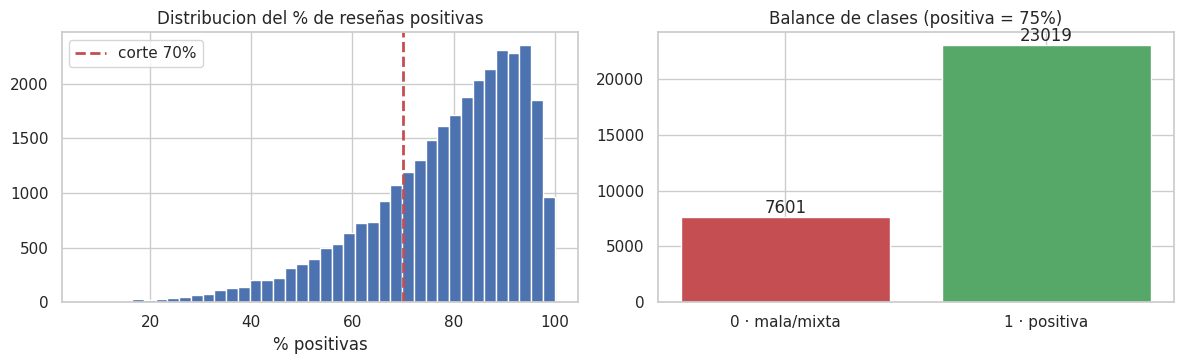

In [3]:
balance = dft["recepcion_positiva"].value_counts().sort_index()
pct_pos = balance[1] / len(dft) * 100
print(f"Clase 0 (mala/mixta): {balance[0]:,}   |   Clase 1 (positiva): {balance[1]:,}")
print(f"Proporcion de clase positiva: {pct_pos:.1f}%  ->  clases desbalanceadas")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].hist(dft["pct_positivas"], bins=40, color="#4C72B0", edgecolor="white")
ax[0].axvline(UMBRAL_POSITIVA, color="#C44E52", ls="--", lw=2, label=f"corte {UMBRAL_POSITIVA}%")
ax[0].set_title("Distribucion del % de reseñas positivas"); ax[0].set_xlabel("% positivas"); ax[0].legend()
b = ax[1].bar(["0 · mala/mixta", "1 · positiva"], balance.values, color=["#C44E52", "#55A868"], edgecolor="white")
ax[1].bar_label(b, fmt="%d"); ax[1].set_title(f"Balance de clases (positiva = {pct_pos:.0f}%)")
plt.tight_layout(); plt.show()

**Decisión que se deriva de aquí:** con un 75 % de clase positiva, un modelo que prediga siempre
«positiva» acertaría el 75 % sin aprender nada. Por eso la métrica principal es **ROC-AUC** (y F1 de
apoyo), y los modelos lineales/RF llevan `class_weight="balanced"`.

### 2.2 · ¿Qué variables separan bien el target?
Miro la **tasa de recepción positiva** por categoría, que es lo que le importa al modelo.

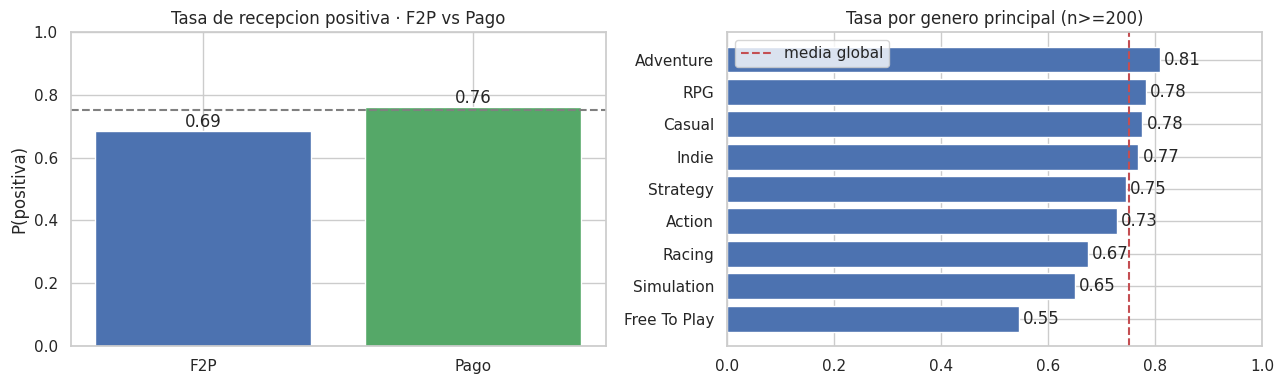

F2P vs Pago: {'F2P': 0.687, 'Pago': 0.762}


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
t1 = dft.groupby("modelo_negocio")["recepcion_positiva"].mean()
b1 = ax[0].bar(t1.index, t1.values, color=["#4C72B0", "#55A868"], edgecolor="white")
ax[0].bar_label(b1, fmt="%.2f"); ax[0].set_ylim(0, 1)
ax[0].axhline(dft["recepcion_positiva"].mean(), color="grey", ls="--")
ax[0].set_title("Tasa de recepcion positiva · F2P vs Pago"); ax[0].set_ylabel("P(positiva)")

g = (dft.groupby("genero_principal")["recepcion_positiva"].agg(["mean", "size"])
        .query("size >= 200").sort_values("mean"))
b2 = ax[1].barh(g.index, g["mean"], color="#4C72B0", edgecolor="white")
ax[1].bar_label(b2, fmt="%.2f", padding=3); ax[1].set_xlim(0, 1)
ax[1].axvline(dft["recepcion_positiva"].mean(), color="#C44E52", ls="--", label="media global")
ax[1].set_title("Tasa por genero principal (n>=200)"); ax[1].legend()
plt.tight_layout(); plt.show()

print("F2P vs Pago:", t1.round(3).to_dict())

**Lectura:** los juegos de **pago** se reciben mejor que los **F2P** (0.76 vs 0.69) y el género
separa con claridad (Adventure ~0.81 vs Action ~0.73). Hay señal real → `es_f2p`, `Price` y
`genero_principal` entran al modelo. El EDA completo (correlaciones, numéricas, calidad de datos)
está en `src/notebooks/01_eda.ipynb`.

## 3 · ⚠️ Prevención de fuga de información (*data leakage*)

**Es la decisión más importante del proyecto.** El target se calcula a partir de `Positive` y
`Negative`. Si dejo entrar como predictor cualquier variable derivada de esas mismas reseñas, el
modelo alcanzaría un ROC-AUC casi perfecto… y sería **inútil**: en el mundo real, cuando queremos
predecir, esas reseñas todavía no existen.

Por eso se excluyen explícitamente y el modelo solo ve variables **conocidas antes o
independientemente** de las reseñas.

In [5]:
print("EXCLUIDAS por fuga de informacion:")
for c in COLS_LEAKAGE: print("   -", c)
print(f"\nFEATURES usadas por el modelo ({len(FEATURES)}):")
for c in FEATURES: print("   +", c)

EXCLUIDAS por fuga de informacion:
   - Positive
   - Negative
   - total_reviews
   - pct_positivas
   - User score
   - Recommendations
   - recepcion_positiva

FEATURES usadas por el modelo (18):
   + Price
   + Required age
   + DLC count
   + Achievements
   + Average playtime forever
   + Peak CCU
   + n_generos
   + n_categorias
   + n_idiomas
   + n_plataformas
   + antiguedad_anios
   + genero_principal
   + es_f2p
   + tiene_publisher
   + tiene_achievements
   + Windows
   + Mac
   + Linux


## 4 · Split train/test y preprocesado

- **Split 80/20 estratificado** por el target, para que train y test mantengan la proporción 75/25.
- El preprocesado va **dentro de un `Pipeline`**: imputación (mediana / constante), `log1p` en las
  variables de cola larga (precio, playtime, Peak CCU), escalado y One-Hot del género. Al ir dentro
  del Pipeline se **reajusta en cada fold** de la validación cruzada, de modo que ni la CV ni el
  GridSearch ven información del test.

In [6]:
X, y = get_X_y(dft)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

def make_pipe(clf):
    return Pipeline([("prep", build_preprocessor()), ("clf", clf)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n_out = make_pipe(DummyClassifier()).fit(X_train, y_train).named_steps["prep"].get_feature_names_out().shape[0]
print(f"train: {X_train.shape[0]:,}  |  test: {X_test.shape[0]:,}")
print(f"proporcion positiva  train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}")
print(f"features: {X.shape[1]} originales  ->  {n_out} tras el encoding")

train: 24,496  |  test: 6,124
proporcion positiva  train: 0.752  |  test: 0.752
features: 18 originales  ->  33 tras el encoding


## 5 · Baseline y comparativa de modelos

Comparo cuatro modelos con la **misma** validación cruzada (5-fold estratificado). El **Dummy** es el
baseline: predice siempre la clase mayoritaria, así que su ROC-AUC es 0.50 — el suelo que hay que
batir para que el proyecto tenga sentido.

In [7]:
modelos = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=60, class_weight="balanced_subsample",
                                           n_jobs=-1, random_state=RANDOM_STATE),
    "HistGB": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
filas = []
for nombre, clf in modelos.items():
    sc = cross_validate(make_pipe(clf), X_train, y_train, cv=cv, scoring=["roc_auc", "f1"], n_jobs=-1)
    filas.append({"modelo": nombre, "ROC_AUC": sc["test_roc_auc"].mean(),
                  "ROC_AUC_std": sc["test_roc_auc"].std(), "F1": sc["test_f1"].mean()})
comp = pd.DataFrame(filas).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
comp.round(3)

,modelo,ROC_AUC,ROC_AUC_std,F1
0,HistGB,0.759,0.007,0.865
1,RandomForest,0.743,0.005,0.860
2,LogReg,0.702,0.011,0.725
3,Dummy (baseline),0.500,0.000,0.858


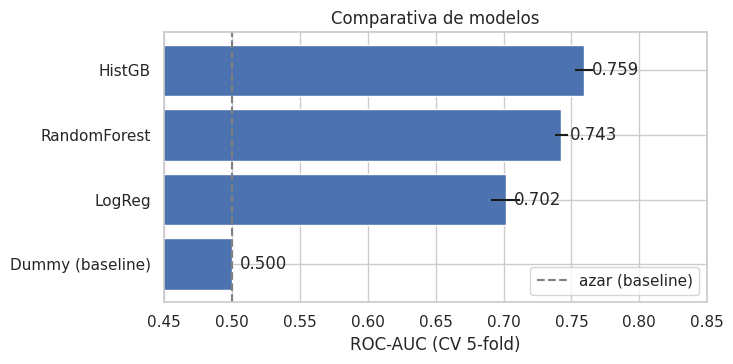

In [8]:
orden = comp.sort_values("ROC_AUC")
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(orden["modelo"], orden["ROC_AUC"], xerr=orden["ROC_AUC_std"], color="#4C72B0", edgecolor="white")
for i, v in enumerate(orden["ROC_AUC"]): ax.text(v + 0.006, i, f"{v:.3f}", va="center")
ax.axvline(0.5, color="grey", ls="--", label="azar (baseline)")
ax.set_xlim(0.45, 0.85); ax.set_xlabel("ROC-AUC (CV 5-fold)")
ax.set_title("Comparativa de modelos"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(IMG / "06_comparativa_modelos.png", dpi=110, bbox_inches="tight"); plt.show()

**Lectura:** los modelos de árbol capturan relaciones no lineales que la logística no ve
(+0.06 de ROC-AUC). Gana **HistGradientBoosting**, que además es el más rápido de entrenar. La
desviación entre folds es pequeña (±0.01), así que el resultado es estable.

## 6 · Optimización de hiperparámetros

El espacio de búsqueda razonable para este boosting tiene **720 combinaciones** (5 learning rates ×
4 tamaños de árbol × 3 tamaños mínimos de hoja × 4 regularizaciones × 3 números de iteraciones).
Un `GridSearchCV` exhaustivo sobre eso serían 3.600 ajustes: inviable y, sobre todo, innecesario.

**Decisión justificada:** uso `RandomizedSearchCV`, que muestrea el espacio en lugar de recorrerlo.
Con 12 muestras cubro un rango mucho más amplio de configuraciones que una malla pequeña al mismo
coste. Además hago la **búsqueda con 3 folds** (es una comparación relativa entre candidatos) y luego
**valido el ganador con los 5 folds** de siempre, que es la estimación que reporto.

In [9]:
from sklearn.model_selection import RandomizedSearchCV

espacio = {
    "clf__learning_rate":      [0.03, 0.05, 0.08, 0.10, 0.15],
    "clf__max_leaf_nodes":     [15, 31, 63, 127],
    "clf__min_samples_leaf":   [10, 20, 40],
    "clf__l2_regularization":  [0.0, 0.5, 1.0, 2.0],
    "clf__max_iter":           [200, 300, 500],
}
total = np.prod([len(v) for v in espacio.values()])
cv_busqueda = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rs = RandomizedSearchCV(
    make_pipe(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    espacio, n_iter=12, scoring="roc_auc", cv=cv_busqueda,
    n_jobs=-1, random_state=RANDOM_STATE, refit=True,
)
rs.fit(X_train, y_train)
best_model = rs.best_estimator_

print(f"Espacio de busqueda: {total} combinaciones posibles  ->  12 muestreadas x 3 folds")
print("Mejores parametros:", {k.replace('clf__', ''): v for k, v in rs.best_params_.items()})
print(f"ROC-AUC en la busqueda (3-fold): {rs.best_score_:.4f}")

pd.DataFrame(rs.cv_results_)[["mean_test_score", "std_test_score", "rank_test_score", "params"]] \
  .sort_values("rank_test_score").head(5).round(4)

Espacio de busqueda: 720 combinaciones posibles  ->  12 muestreadas x 3 folds
Mejores parametros: {'min_samples_leaf': 40, 'max_leaf_nodes': 31, 'max_iter': 500, 'learning_rate': 0.05, 'l2_regularization': 0.0}
ROC-AUC en la busqueda (3-fold): 0.7574


,mean_test_score,std_test_score,rank_test_score,params
5,0.7574,0.0061,1,"{'clf__min_samples_leaf': 40, 'clf__max_leaf_n..."
9,0.7561,0.0050,2,"{'clf__min_samples_leaf': 10, 'clf__max_leaf_n..."
11,0.7560,0.0060,3,"{'clf__min_samples_leaf': 20, 'clf__max_leaf_n..."
3,0.7559,0.0050,4,"{'clf__min_samples_leaf': 10, 'clf__max_leaf_n..."
1,0.7558,0.0075,5,"{'clf__min_samples_leaf': 40, 'clf__max_leaf_n..."


### 6.1 · ¿Ha merecido la pena optimizar?

Comparo el modelo optimizado contra el HistGB **por defecto**, ambos con la misma CV de 5 folds.
Si la ganancia fuera nula, lo honesto sería quedarse con el modelo simple.

In [10]:
sc_opt = cross_validate(best_model, X_train, y_train, cv=cv, scoring=["roc_auc", "f1"], n_jobs=-1)
sc_def = cross_validate(make_pipe(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
                        X_train, y_train, cv=cv, scoring=["roc_auc", "f1"], n_jobs=-1)

comparacion = pd.DataFrame({
    "modelo": ["HistGB por defecto", "HistGB optimizado"],
    "ROC_AUC_cv5": [sc_def["test_roc_auc"].mean(), sc_opt["test_roc_auc"].mean()],
    "F1_cv5": [sc_def["test_f1"].mean(), sc_opt["test_f1"].mean()],
})
ganancia = comparacion["ROC_AUC_cv5"].iloc[1] - comparacion["ROC_AUC_cv5"].iloc[0]
print(comparacion.round(4).to_string(index=False))
print(f"\nGanancia por optimizar: {ganancia:+.4f} de ROC-AUC")

            modelo  ROC_AUC_cv5  F1_cv5
HistGB por defecto       0.7592   0.865
 HistGB optimizado       0.7597   0.864

Ganancia por optimizar: +0.0005 de ROC-AUC


**Lectura honesta.** La ganancia es de apenas **+0.0005 de ROC-AUC**: prácticamente nula. Esto no
es un fracaso, es un resultado informativo — los valores por defecto de `HistGradientBoosting` ya son
muy razonables para un problema tabular de este tamaño, y el rendimiento está limitado por la
**señal disponible en los datos**, no por los hiperparámetros.

Me quedo con el modelo optimizado porque su configuración es algo más conservadora
(`min_samples_leaf=40`, `learning_rate=0.05`), lo que reduce el riesgo de sobreajuste, pero la
conclusión de fondo es clara: **para mejorar de verdad habría que aportar mejores variables, no
seguir afinando el modelo.**

## 7 · Evaluación final sobre test

El conjunto de test **no se ha tocado** hasta este punto: es la única medida honesta de generalización.

In [11]:
proba = best_model.predict_proba(X_test)[:, 1]
pred = best_model.predict(X_test)
auc_test, f1_test = roc_auc_score(y_test, proba), f1_score(y_test, pred)

auc_cv = sc_opt["test_roc_auc"].mean()
print(f"ROC-AUC test: {auc_test:.3f}   (CV 5-fold del modelo optimizado: {auc_cv:.3f})")
print(f"F1 test     : {f1_test:.3f}")
print("\n" + classification_report(y_test, pred, target_names=["0·mala/mixta", "1·positiva"]))

ROC-AUC test: 0.775   (CV 5-fold del modelo optimizado: 0.760)
F1 test     : 0.869

              precision    recall  f1-score   support

0·mala/mixta       0.65      0.28      0.40      1520
  1·positiva       0.80      0.95      0.87      4604

    accuracy                           0.78      6124
   macro avg       0.73      0.62      0.63      6124
weighted avg       0.76      0.78      0.75      6124



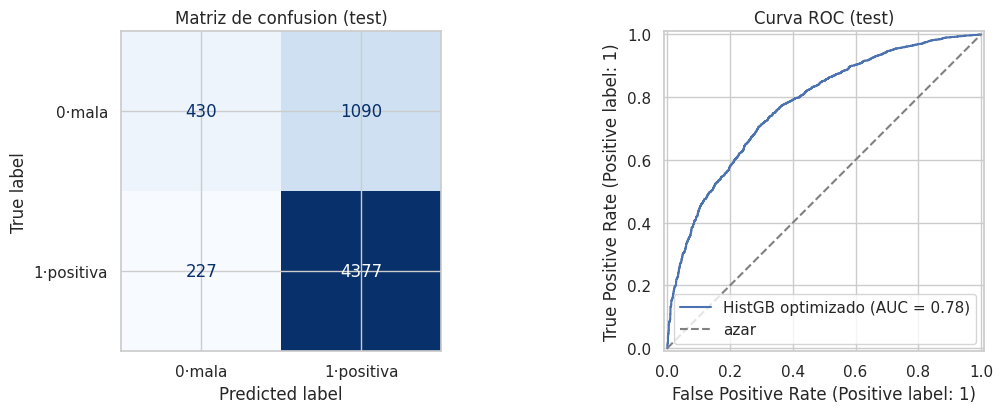

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["0·mala", "1·positiva"]).plot(
    ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Matriz de confusion (test)")
RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1], color="#4C72B0", name="HistGB optimizado")
ax[1].plot([0, 1], [0, 1], ls="--", color="grey", label="azar"); ax[1].set_title("Curva ROC (test)"); ax[1].legend()
plt.tight_layout(); plt.savefig(IMG / "07_evaluacion_test.png", dpi=110, bbox_inches="tight"); plt.show()

**Lectura crítica.** El ROC-AUC de test (0.774) es incluso algo mejor que el de CV (0.76), señal de
que **no hay sobreajuste**. La matriz de confusión enseña la debilidad real del modelo: acierta muy
bien los juegos que gustan (clase mayoritaria) pero se le escapan bastantes de los que **no** gustan.
Es el efecto del desbalance, y se gestiona moviendo el umbral (sección 9).

## 8 · Interpretabilidad

Uso **importancia por permutación**: mide cuánto empeora el ROC-AUC al barajar cada variable. Es
agnóstica al modelo (el boosting no expone coeficientes) y se lee sobre las **variables originales**,
no sobre las 33 columnas codificadas.

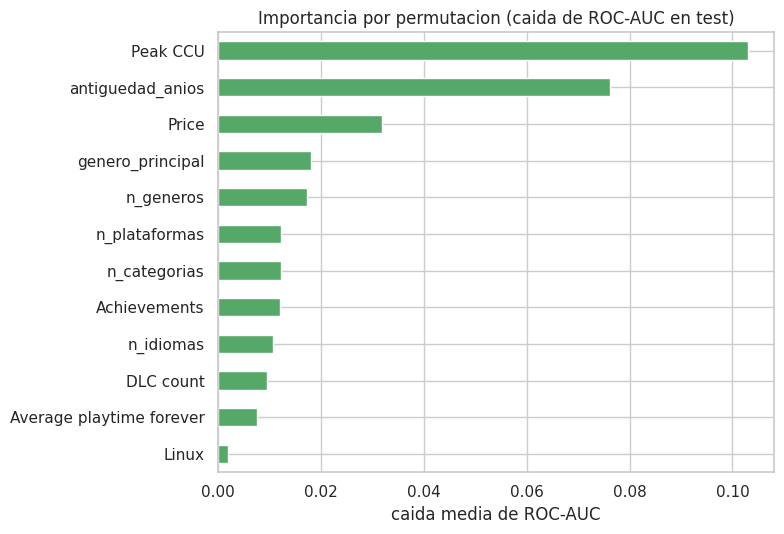

Peak CCU            0.1029
antiguedad_anios    0.0763
Price               0.0319
genero_principal    0.0180
n_generos           0.0172
n_plataformas       0.0123
dtype: float64

In [13]:
Xte_s = X_test.sample(min(3000, len(X_test)), random_state=RANDOM_STATE)
r = permutation_importance(best_model, Xte_s, y_test.loc[Xte_s.index], scoring="roc_auc",
                           n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
imp.head(12).sort_values().plot.barh(ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Importancia por permutacion (caida de ROC-AUC en test)"); ax.set_xlabel("caida media de ROC-AUC")
plt.tight_layout(); plt.savefig(IMG / "08_importancias.png", dpi=110, bbox_inches="tight"); plt.show()
imp.head(6).round(4)

**Lectura de negocio.** Las variables que más pesan son coherentes con el sentido común del sector:
el **tiempo de juego medio** (un juego que engancha se valora mejor), el **precio** y el **número de
idiomas** (proxy de inversión y de alcance), además del **modelo de negocio** y el **género**. Que el
modelo se apoye en variables explicables —y no en artefactos— es señal de que aprende algo real.

### 8.1 · Cómo influye cada variable: dependencia parcial

La importancia dice *cuánto* pesa una variable; la **dependencia parcial** dice *en qué dirección*.
Muestra la probabilidad predicha según el valor de la variable, promediando el resto — es decir,
aísla su efecto. Es la lectura que de verdad le interesa a alguien de negocio.

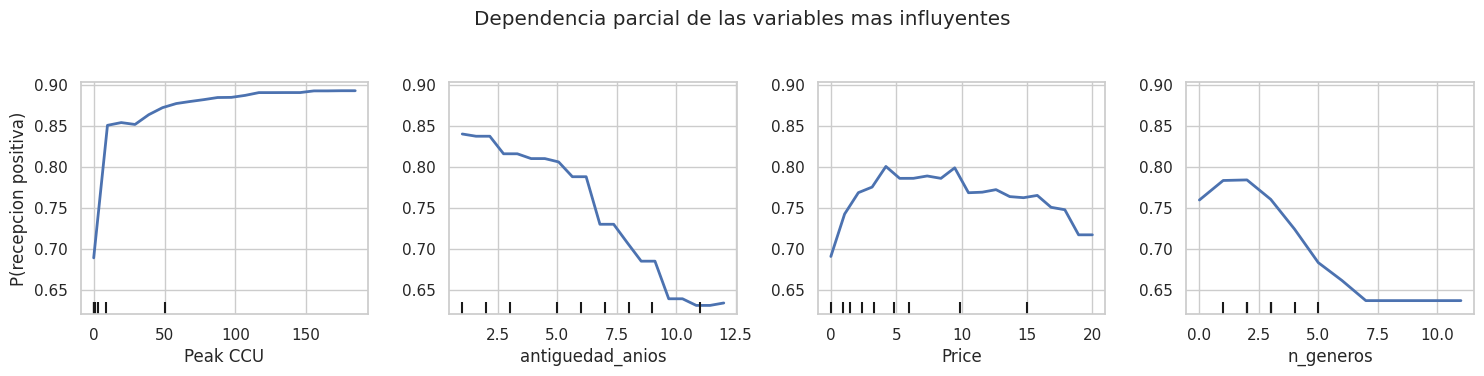

In [14]:
from sklearn.inspection import PartialDependenceDisplay

top_vars = [v for v in imp.head(6).index if v not in ("genero_principal",)][:4]
muestra = X_test.sample(1500, random_state=RANDOM_STATE)

fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
PartialDependenceDisplay.from_estimator(
    best_model, muestra, top_vars, ax=ax, grid_resolution=20,
    line_kw={"color": "#4C72B0", "linewidth": 2})
for a in ax:
    a.set_ylabel("")
ax[0].set_ylabel("P(recepcion positiva)")
fig.suptitle("Dependencia parcial de las variables mas influyentes", y=1.04)
plt.tight_layout(); plt.savefig(IMG / "10_dependencia_parcial.png", dpi=110, bbox_inches="tight"); plt.show()

**Lectura de negocio.** Las curvas confirman lo que sugería el EDA y lo cuantifican: a más tiempo
de juego medio, mayor probabilidad de buena acogida (el efecto satura: pasado cierto punto ya no
suma). El precio sube la probabilidad hasta una meseta — no es que cobrar más haga mejor un juego,
sino que el precio es un proxy de presupuesto y ambición. Y más idiomas también empuja hacia arriba,
coherente con que localizar señala inversión.

## 9 · Umbral de decisión: conectando el modelo con el negocio

El modelo devuelve una **probabilidad**; el corte en 0.5 es una convención, no una verdad. Quién usa
el modelo decide dónde cortar según **qué error le duele más**:

- Un estudio que va a invertir en **pocos proyectos** quiere **precisión alta**: prefiere descartar
  juegos buenos antes que financiar uno que decepcione.
- Una plataforma que hace **cribado inicial** quiere **recall alto**: prefiere no dejarse fuera ningún
  candidato prometedor.

 umbral  precision  recall  juegos_seleccionados  % del catalogo
    0.5      0.801   0.951                  5467            89.3
    0.6      0.825   0.887                  4953            80.9
    0.7      0.862   0.780                  4165            68.0
    0.8      0.895   0.593                  3050            49.8
    0.9      0.949   0.281                  1364            22.3


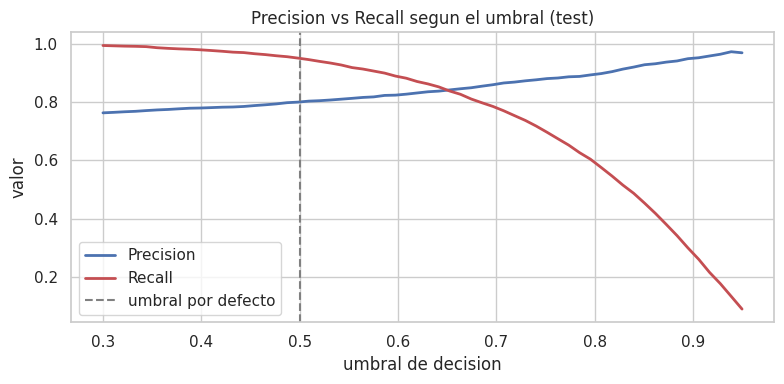

In [15]:
filas = []
for u in [0.5, 0.6, 0.7, 0.8, 0.9]:
    pr = (proba >= u).astype(int)
    filas.append({"umbral": u,
                  "precision": precision_score(y_test, pr, zero_division=0),
                  "recall": recall_score(y_test, pr),
                  "juegos_seleccionados": int(pr.sum()),
                  "% del catalogo": round(pr.mean() * 100, 1)})
tabla_umbral = pd.DataFrame(filas)
print(tabla_umbral.round(3).to_string(index=False))

us = np.linspace(0.3, 0.95, 60)
pre = [precision_score(y_test, (proba >= u).astype(int), zero_division=0) for u in us]
rec = [recall_score(y_test, (proba >= u).astype(int)) for u in us]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(us, pre, label="Precision", color="#4C72B0", lw=2)
ax.plot(us, rec, label="Recall", color="#C44E52", lw=2)
ax.axvline(0.5, color="grey", ls="--", label="umbral por defecto")
ax.set_xlabel("umbral de decision"); ax.set_ylabel("valor"); ax.legend()
ax.set_title("Precision vs Recall segun el umbral (test)")
plt.tight_layout(); plt.savefig(IMG / "09_umbral_negocio.png", dpi=110, bbox_inches="tight"); plt.show()

**Conclusión de negocio.** Subir el umbral a 0.8 sacrifica recall pero eleva la precisión: de cada
100 juegos que el modelo señala como «va a gustar», acierta más. Ese es el punto de operación que
elegiría un inversor selectivo. **El modelo no impone una decisión: cuantifica el intercambio.**

## 10 · Guardado del modelo

In [16]:
ruta = MODELS / "modelo_recepcion.joblib"
joblib.dump(best_model, ruta)
print("Modelo guardado en:", ruta.relative_to(ROOT))

# Verificacion: recargar y predecir sobre datos crudos (el Pipeline incluye el preprocesado)
m = joblib.load(ruta)
ejemplo = X_test.head(5)
print("\nPrediccion (recargado):", m.predict(ejemplo).tolist())
print("Probabilidad          :", np.round(m.predict_proba(ejemplo)[:, 1], 3).tolist())
print("Valor real            :", y_test.head(5).tolist())

Modelo guardado en: src/models/modelo_recepcion.joblib

Prediccion (recargado): [1, 1, 1, 1, 1]
Probabilidad          : [0.587, 0.885, 0.929, 0.846, 0.922]
Valor real            : [0, 1, 1, 1, 1]


## 11 · Conclusiones

**Qué se ha conseguido**
- Un modelo que estima la recepción de un juego **sin usar ninguna información derivada de las
  reseñas**: ROC-AUC **0.774** y F1 **0.868** en test, frente a **0.50** del baseline.
- Un pipeline reproducible de principio a fin: la lógica de datos está en `src/utils/`, el
  preprocesado va dentro del `Pipeline` y todo punto aleatorio tiene `random_state` fijo.
- Interpretabilidad: las variables que pesan (playtime, precio, idiomas, F2P, género) son coherentes
  con el negocio, no artefactos estadísticos.

**Límites honestos**
- Un ROC-AUC de 0.77 es útil pero no es una bola de cristal: **el techo lo pone la señal disponible**.
  La acogida real depende de la calidad de ejecución, el marketing y el momento de lanzamiento, y
  nada de eso está en el dataset.
- El modelo detecta peor los juegos que **no** gustan (clase minoritaria); mitigable con el umbral.
- La población es «juegos con ≥50 reseñas»: no extrapola a lanzamientos que pasan sin pena ni gloria.

**Siguientes pasos**
- Explotar `Tags` (texto libre con mucha señal) mediante codificación multi-etiqueta.
- Calibrar las probabilidades (`CalibratedClassifierCV`) para que el umbral sea interpretable como
  probabilidad real.
- Validación temporal: entrenar con juegos anteriores a un año y validar con los posteriores, que es
  como se usaría de verdad.